In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 👉 Paste your path
file_path = r"C:\Users\BMSCECSE-SH\Downloads\ML Lab 4 (3)\ML Lab 4\Logistic Regression\HR_comma_sep.csv"

# Load data
df = pd.read_csv(file_path)

# 👉 Encode categorical columns
df['salary'] = df['salary'].map({'low': 0, 'medium': 1, 'high': 2})

# 🔥 IMPORTANT FIX (Department)
df = pd.get_dummies(df, columns=['Department'], drop_first=True)

# Features & target
X = df.drop('left', axis=1)
y = df['left']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7886666666666666

Confusion Matrix:
 [[2117  177]
 [ 457  249]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87      2294
           1       0.58      0.35      0.44       706

    accuracy                           0.79      3000
   macro avg       0.70      0.64      0.65      3000
weighted avg       0.77      0.79      0.77      3000



In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 👉 Paste your file path
file_path = r"C:\Users\BMSCECSE-SH\Downloads\ML Lab 4 (3)\ML Lab 4\Logistic Regression\HR_comma_sep.csv"

# Load dataset
df = pd.read_csv(file_path)

# 👉 Convert categorical data
df['salary'] = df['salary'].map({'low': 0, 'medium': 1, 'high': 2})
df = pd.get_dummies(df, columns=['Department'], drop_first=True)

# 👉 Features (X) and Target (y)
X = df.drop('left', axis=1)
y = df['left']   # 0 = Stay, 1 = Leave

# 👉 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 👉 Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 👉 Binary Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 👉 Predictions
y_pred = model.predict(X_test)

# 👉 Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# 👉 Show few predictions with probability
y_prob = model.predict_proba(X_test)

print("\nSample Predictions:")
for i in range(5):
    print(f"Actual: {y_test.iloc[i]}, Predicted: {y_pred[i]}, Probability of Leaving: {y_prob[i][1]:.2f}")

Accuracy: 0.7886666666666666

Sample Predictions:
Actual: 0, Predicted: 0, Probability of Leaving: 0.02
Actual: 0, Predicted: 0, Probability of Leaving: 0.08
Actual: 0, Predicted: 0, Probability of Leaving: 0.24
Actual: 1, Predicted: 0, Probability of Leaving: 0.49
Actual: 0, Predicted: 0, Probability of Leaving: 0.03


First 5 rows:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  


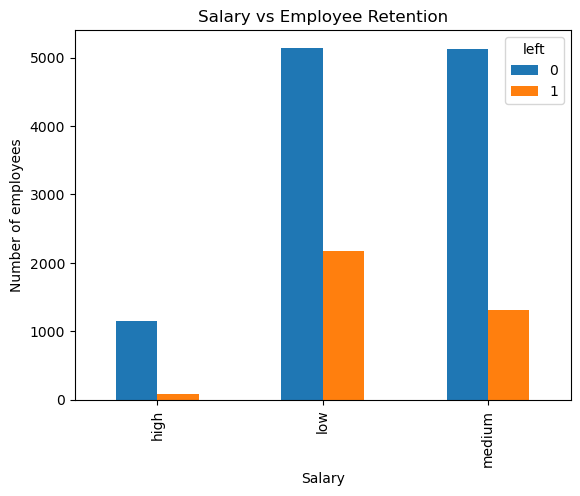

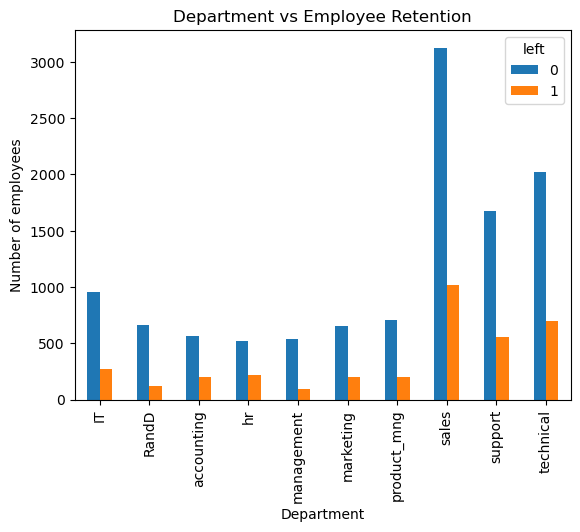


Accuracy = 0.7706666666666667

Confusion Matrix:
[[2119  147]
 [ 541  193]]

Model Coefficients:
[[-3.79108213e+00  2.18465179e-03 -1.00113129e+00 -1.08874818e+00
   8.03958810e-01  3.16141813e-01]]

Model Intercept:
[0.01961309]

Sample Predictions:
[0 0 0 0 0 0 0 0 0 0]


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

file_path = r"C:\Users\BMSCECSE-SH\Downloads\ML Lab 4 (3)\ML Lab 4\Logistic Regression\HR_comma_sep.csv"

# Load dataset
df = pd.read_csv(file_path)


print("First 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

# Correlation matrix
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))

# Salary vs retention
pd.crosstab(df.salary,df.left).plot(kind='bar')

plt.title("Salary vs Employee Retention")
plt.xlabel("Salary")
plt.ylabel("Number of employees")

plt.show()

# Department vs retention
pd.crosstab(df.Department,df.left).plot(kind='bar')

plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Number of employees")

plt.show()

# Select important features
X = df[['satisfaction_level',
        'average_montly_hours',
        'promotion_last_5years']]

# Salary encoding
salary = pd.get_dummies(df.salary)

X = pd.concat([X,salary],axis=1)

y = df.left

# Train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=10)

# Logistic regression model
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test,y_pred)

print("\nAccuracy =",accuracy)

# Confusion matrix
cm = confusion_matrix(y_test,y_pred)

print("\nConfusion Matrix:")
print(cm)

# Logistic coefficients
print("\nModel Coefficients:")
print(model.coef_)

print("\nModel Intercept:")
print(model.intercept_)

# Sample predictions
print("\nSample Predictions:")
print(y_pred[:10])

Accuracy: 0.9523809523809523

Confusion Matrix (values):
 [[12  0  0  0  0  0]
 [ 0  2  0  0  0  0]
 [ 0  0  0  1  0  0]
 [ 0  0  0  2  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  1]]


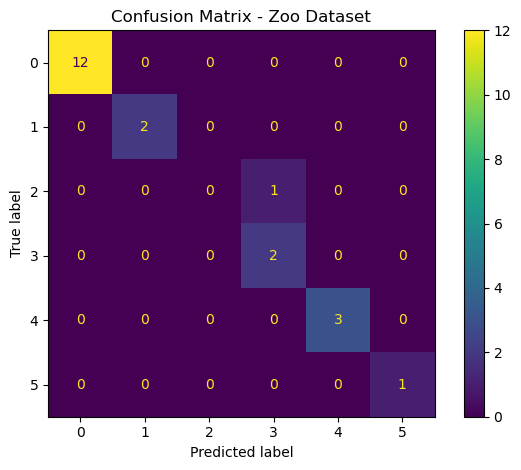

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 👉 Paste your file path
zoo_data_path = r"C:\Users\BMSCECSE-SH\Downloads\ML Lab 4 (3)\ML Lab 4\Logistic Regression\zoo-data.csv"
# Load dataset
zoo = pd.read_csv(zoo_data_path)

# Drop non-numeric column
zoo = zoo.drop('animal_name', axis=1)

# Features & target
X = zoo.drop('class_type', axis=1)
y = zoo['class_type']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# 👉 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix (values):\n", cm)   # 👈 ALWAYS PRINT THIS

# 👉 Plot (FORCE DISPLAY)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Zoo Dataset")

plt.tight_layout()   # fixes layout issues
plt.show()           # 👈 VERY IMPORTANT